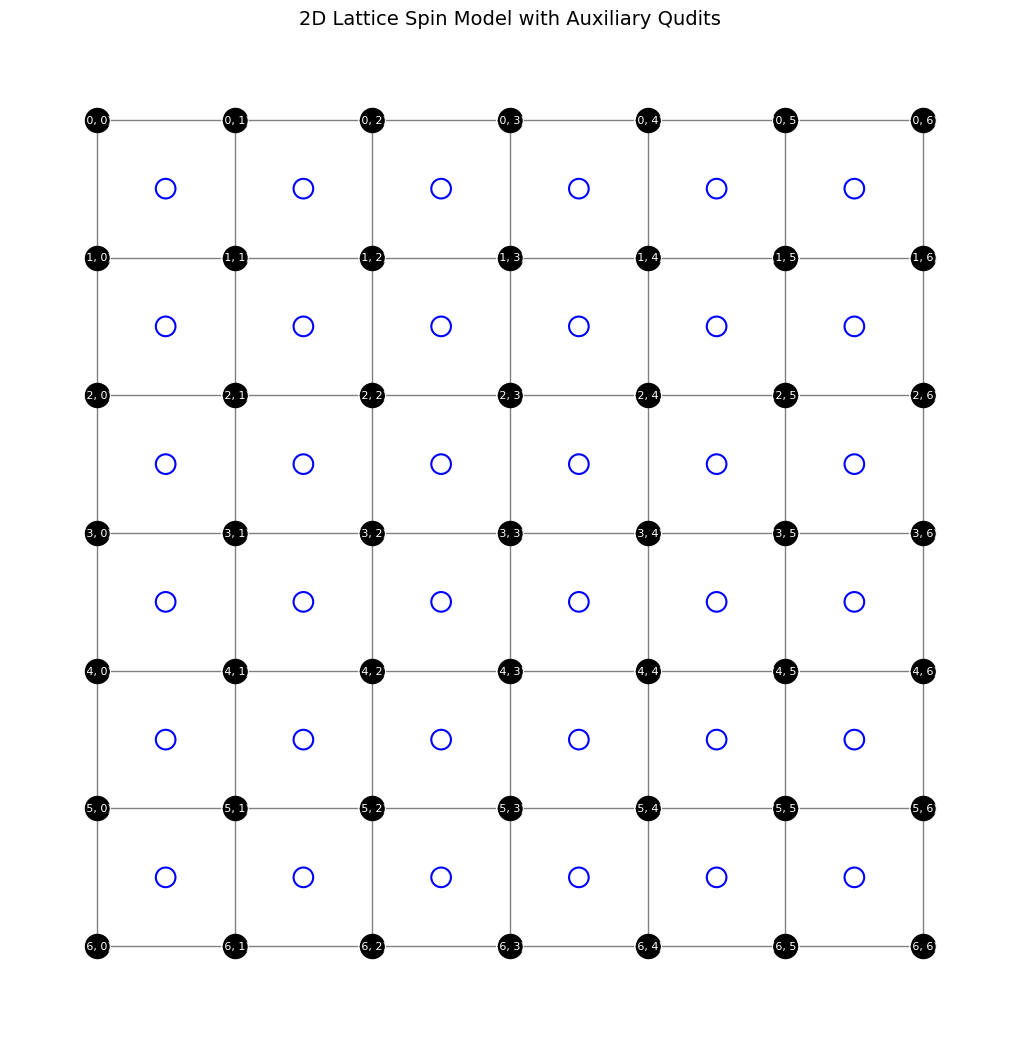

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Parameters for the lattice
rows, cols = 7, 7  # Number of rows and columns for the lattice
spacing = 1  # Distance between points

# Create a 2D lattice graph
G = nx.grid_2d_graph(rows, cols)

# Positions for the nodes
pos = {node: (node[1] * spacing, -node[0] * spacing) for node in G.nodes()}

# Define auxiliary qudit positions (open circles)
aux_positions = []
for i in range(rows - 1):
    for j in range(cols - 1):
        aux_positions.append(((j + 0.5) * spacing, -(i + 0.5) * spacing))

# Plot the lattice with interactions and auxiliary qudits
plt.figure(figsize=(10, 10))
nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=300,
    node_color="black",
    edge_color="gray",
    linewidths=1,
)
# Add auxiliary qudit positions as open circles
for aux_pos in aux_positions:
    plt.scatter(*aux_pos, s=200, facecolors="none", edgecolors="blue", linewidths=1.5)

# Add labels for clarity (optional)
for node, (x, y) in pos.items():
    plt.text(x, y, f"{node}", fontsize=8, ha="center", va="center", color="white")

plt.title("2D Lattice Spin Model with Auxiliary Qudits", fontsize=14)
plt.axis("off")
plt.show()

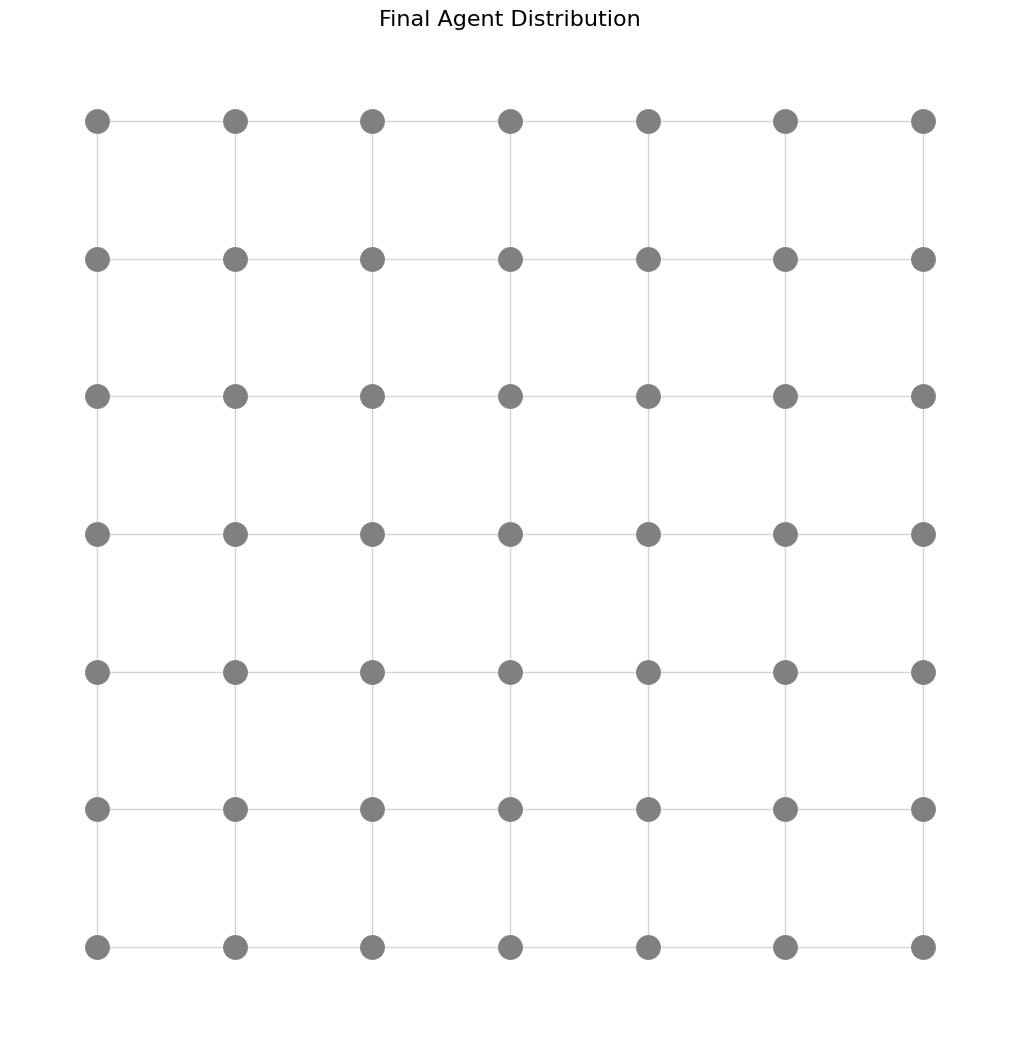

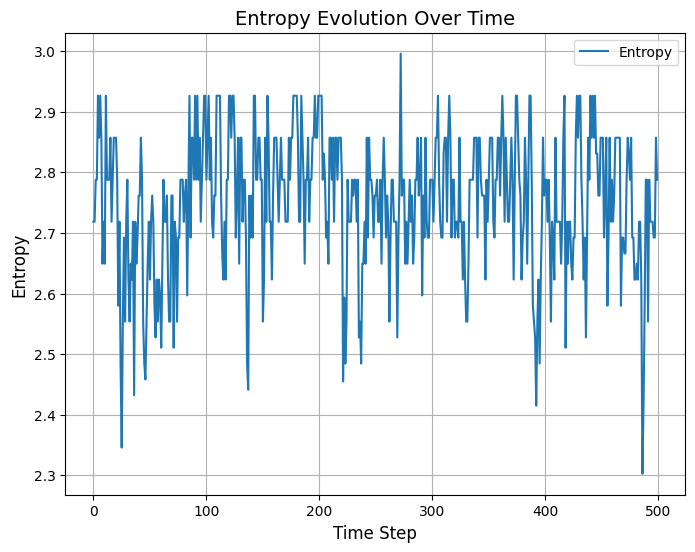

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Parameters for the simulation
num_agents = 20  # Number of agents to place randomly on the lattice
time_steps = 500  # Number of time steps for the simulation
rows, cols = 7, 7  # Dimensions of the lattice
prob_move = 0.3  # Probability of an agent moving at each step

# Create a 2D lattice
G = nx.grid_2d_graph(rows, cols)
positions = {node: (node[1], -node[0]) for node in G.nodes()}

# Initialize agents at random positions
nodes = list(G.nodes())
agents = np.random.choice(len(nodes), size=num_agents, replace=True)

# Function to calculate entropy
def calculate_entropy(agent_positions, num_nodes):
    counts = np.bincount(agent_positions, minlength=num_nodes)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

# Simulation loop
history = []
for t in range(time_steps):
    # Record the current state
    history.append(agents.copy())

    # Update agent positions
    for i in range(len(agents)):
        if np.random.rand() < prob_move:
            current_node = nodes[agents[i]]
            neighbors = [nodes.index(neighbor) for neighbor in G.neighbors(current_node)]
            if len(neighbors) > 0:
                new_node_index = np.random.choice(neighbors)
                agents[i] = new_node_index

# Calculate entropy over time
num_nodes = len(G.nodes())
entropies = [calculate_entropy(np.array(h), num_nodes) for h in history]

# Visualize final state
plt.figure(figsize=(10, 10))
nx.draw(
    G,
    positions,
    with_labels=False,
    node_size=300,
    node_color="gray",
    edge_color="lightgray",
    linewidths=0.5,
)
agent_positions = {node: 0 for node in G.nodes()}
for agent in agents:
    agent_positions[nodes[agent]] += 1

for node, count in agent_positions.items():
    if count > 0:
        x, y = positions[node]
        plt.scatter(x, y, s=200, color="blue", alpha=0.6 + 0.4 * count / max(agent_positions.values()))

plt.title("Final Agent Distribution", fontsize=16)
plt.axis("off")
plt.show()

# Plot entropy over time
plt.figure(figsize=(8, 6))
plt.plot(range(time_steps), entropies, label="Entropy")
plt.xlabel("Time Step", fontsize=12)
plt.ylabel("Entropy", fontsize=12)
plt.title("Entropy Evolution Over Time", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

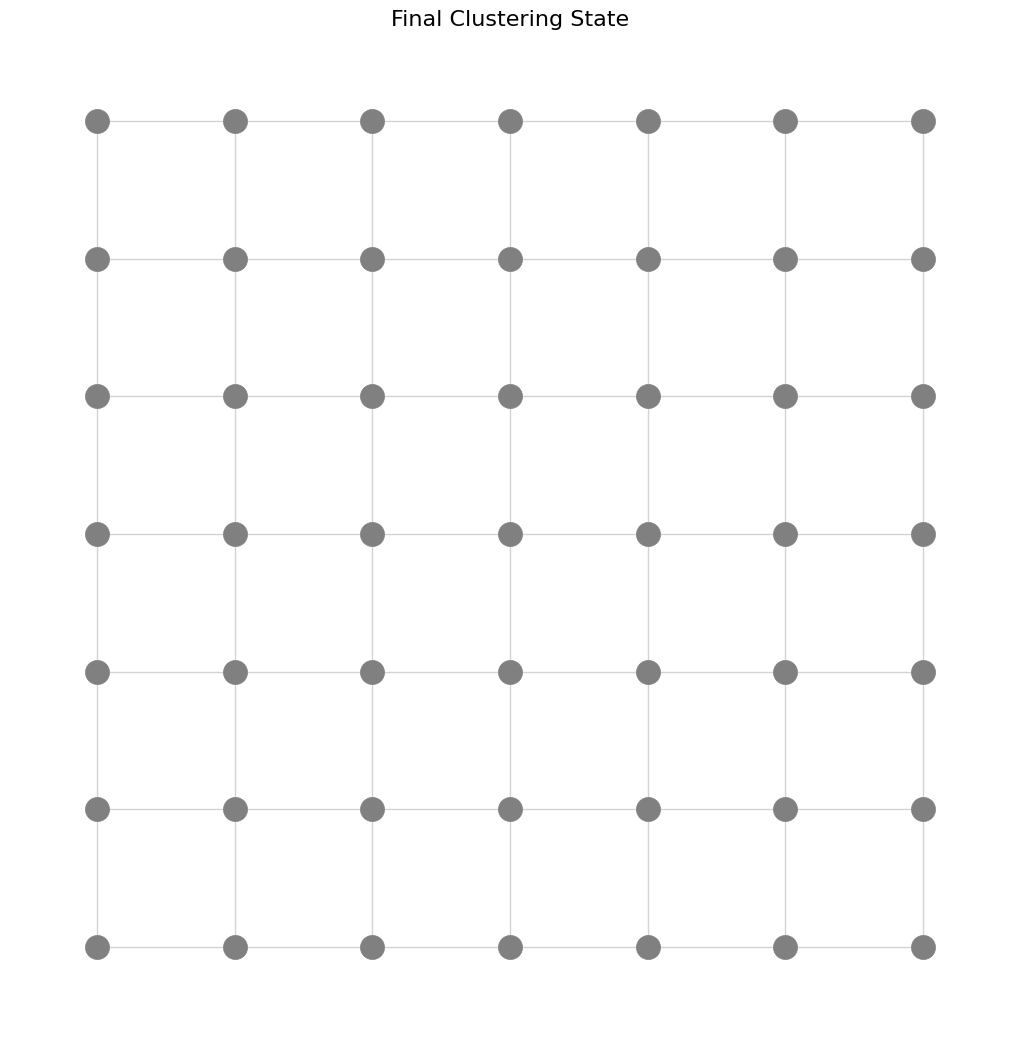

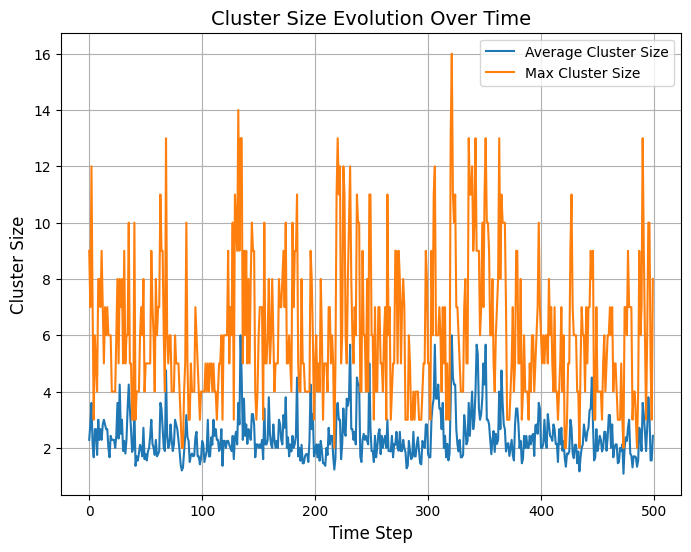

In [ ]:
from collections import defaultdict

# Function to find clusters using BFS
def find_clusters(agent_positions, nodes, G):
    visited = set()
    clusters = []

    for agent in agent_positions:
        if agent not in visited:
            cluster = set()
            queue = [agent]
            while queue:
                current = queue.pop()
                if current not in visited:
                    visited.add(current)
                    cluster.add(current)
                    neighbors = [nodes.index(n) for n in G.neighbors(nodes[current]) if nodes.index(n) in agent_positions]
                    queue.extend(neighbors)
            clusters.append(cluster)
    return clusters

# Simulation with clustering analysis
history_clusters = []
for t in range(time_steps):
    # Record current state
    history_clusters.append(find_clusters(agents, nodes, G))

    # Update agent positions
    for i in range(len(agents)):
        if np.random.rand() < prob_move:
            current_node = nodes[agents[i]]
            neighbors = [nodes.index(neighbor) for neighbor in G.neighbors(current_node)]
            if len(neighbors) > 0:
                new_node_index = np.random.choice(neighbors)
                agents[i] = new_node_index

# Visualize final clustering state
final_clusters = find_clusters(agents, nodes, G)
cluster_colors = plt.cm.tab20(np.linspace(0, 1, len(final_clusters)))

plt.figure(figsize=(10, 10))
nx.draw(
    G,
    positions,
    with_labels=False,
    node_size=300,
    node_color="gray",
    edge_color="lightgray",
    linewidths=0.5,
)
for cluster_idx, cluster in enumerate(final_clusters):
    for agent in cluster:
        x, y = positions[nodes[agent]]
        plt.scatter(x, y, s=200, color=cluster_colors[cluster_idx], alpha=0.8)

plt.title("Final Clustering State", fontsize=16)
plt.axis("off")
plt.show()

# Analyze cluster size evolution
cluster_sizes_over_time = [[len(cluster) for cluster in clusters] for clusters in history_clusters]
avg_cluster_sizes = [np.mean(sizes) for sizes in cluster_sizes_over_time]
max_cluster_sizes = [max(sizes) for sizes in cluster_sizes_over_time]

# Plot cluster size evolution
plt.figure(figsize=(8, 6))
plt.plot(range(time_steps), avg_cluster_sizes, label="Average Cluster Size")
plt.plot(range(time_steps), max_cluster_sizes, label="Max Cluster Size")
plt.xlabel("Time Step", fontsize=12)
plt.ylabel("Cluster Size", fontsize=12)
plt.title("Cluster Size Evolution Over Time", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import networkx as nx
import numpy as np

# Parameters
rows, cols = 7, 7  # Lattice dimensions
num_epochs = 10  # Training epochs
batch_size = 64  # Batch size
learning_rate = 0.01  # Learning rate
input_size = 28 * 28  # Flattened input image size
output_size = 10  # Fashion MNIST classes
hidden_size = rows * cols  # Number of nodes in the lattice

# Create lattice graph
G = nx.grid_2d_graph(rows, cols)
nodes = list(G.nodes())

# Neural network class based on the lattice
class LatticeNeuralNetwork(nn.Module):
    def __init__(self, G, input_size, hidden_size, output_size):
        super(LatticeNeuralNetwork, self).__init__()
        self.G = G
        self.input_to_hidden = nn.Linear(input_size, hidden_size)
        self.hidden_to_hidden = nn.ModuleDict({
            f"{i}-{j}": nn.Linear(1, 1) for i, j in G.edges()
        })
        self.hidden_to_output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Input to hidden layer
        hidden = self.input_to_hidden(x)
        hidden = torch.sigmoid(hidden)

        # Hidden to hidden layer (lattice interactions)
        hidden_state = hidden.clone()
        for i, j in self.G.edges():
            idx_i, idx_j = nodes.index(i), nodes.index(j)
            interaction = self.hidden_to_hidden[f"{i}-{j}"](hidden[:, idx_i:idx_i+1])
            hidden_state[:, idx_j] += interaction.squeeze()

        # Hidden to output layer
        output = self.hidden_to_output(hidden_state)
        return output

# Load and preprocess Fashion MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Use only 10% of the dataset for training
train_size = int(0.1 * len(train_dataset))
train_subset, _ = torch.utils.data.random_split(train_dataset, [train_size, len(train_dataset) - train_size])

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the network, loss function, and optimizer
model = LatticeNeuralNetwork(G, input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training loop
print("Training started...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)  # Flatten images

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Testing loop
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 6.19MB/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

Training started...
Epoch [1/10], Loss: 2.1827
Epoch [2/10], Loss: 1.8603
Epoch [3/10], Loss: 1.6051
Epoch [4/10], Loss: 1.4181
Epoch [5/10], Loss: 1.2795
Epoch [6/10], Loss: 1.1714
Epoch [7/10], Loss: 1.0828
Epoch [8/10], Loss: 1.0100
Epoch [9/10], Loss: 0.9491
Epoch [10/10], Loss: 0.8991
Test Accuracy: 72.20%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Parameters
rows, cols = 7, 7  # Lattice dimensions
num_epochs = 10  # Training epochs
batch_size = 64  # Batch size
learning_rate = 0.01  # Learning rate
input_size = 28 * 28  # Flattened input image size
output_size = 10  # Fashion MNIST classes
hidden_size = rows * cols  # Number of hidden neurons

# Standard feedforward neural network class
class StandardNeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(StandardNeuralNetwork, self).__init__()
        self.input_to_hidden = nn.Linear(input_size, hidden_size)
        self.hidden_to_hidden = nn.Linear(hidden_size, hidden_size)
        self.hidden_to_output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Input to hidden layer
        hidden = torch.sigmoid(self.input_to_hidden(x))
        # Hidden to hidden layer
        hidden = torch.sigmoid(self.hidden_to_hidden(hidden))
        # Hidden to output layer
        output = self.hidden_to_output(hidden)
        return output

# Load and preprocess Fashion MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Use only 10% of the dataset for training
train_size = int(0.1 * len(train_dataset))
train_subset, _ = torch.utils.data.random_split(train_dataset, [train_size, len(train_dataset) - train_size])

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the network, loss function, and optimizer
model = StandardNeuralNetwork(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training loop
print("Training started...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)  # Flatten images

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Testing loop
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Training started...
Epoch [1/10], Loss: 2.3440
Epoch [2/10], Loss: 2.3031
Epoch [3/10], Loss: 2.2972
Epoch [4/10], Loss: 2.2938
Epoch [5/10], Loss: 2.2907
Epoch [6/10], Loss: 2.2873
Epoch [7/10], Loss: 2.2833
Epoch [8/10], Loss: 2.2793
Epoch [9/10], Loss: 2.2746
Epoch [10/10], Loss: 2.2694
Test Accuracy: 36.61%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import networkx as nx
import numpy as np

# Parameters
rows, cols = 7, 7  # Lattice dimensions
num_epochs = 10  # Training epochs
batch_size = 64  # Batch size
learning_rate = 0.01  # Learning rate
input_size = 28 * 28  # Flattened input image size
output_size = 10  # Fashion MNIST classes
hidden_size = rows * cols  # Number of lattice nodes
qudit_dim = 3  # Dimension of the qudit (e.g., 3 for qutrits)

# Create lattice graph
G = nx.grid_2d_graph(rows, cols)
nodes = list(G.nodes())

# Qudit-based lattice neural network class
class QuditLatticeNeuralNetwork(nn.Module):
    def __init__(self, G, input_size, hidden_size, output_size, qudit_dim):
        super(QuditLatticeNeuralNetwork, self).__init__()
        self.G = G
        self.qudit_dim = qudit_dim
        self.input_to_hidden = nn.Linear(input_size, hidden_size * qudit_dim)
        self.hidden_to_hidden = nn.ModuleDict({
            f"{i}-{j}": nn.Linear(qudit_dim, qudit_dim) for i, j in G.edges()
        })
        self.hidden_to_output = nn.Linear(hidden_size * qudit_dim, output_size)

    def forward(self, x):
        # Input to hidden layer
        hidden = self.input_to_hidden(x)
        hidden = hidden.view(hidden.size(0), len(nodes), self.qudit_dim)  # Reshape for qudits
        hidden = torch.sigmoid(hidden)

        # Hidden to hidden layer (qudit interactions)
        hidden_state = hidden.clone()
        for i, j in self.G.edges():
            idx_i, idx_j = nodes.index(i), nodes.index(j)
            interaction = self.hidden_to_hidden[f"{i}-{j}"](hidden[:, idx_i])
            hidden_state[:, idx_j] += interaction

        # Flatten for output layer
        hidden_state = hidden_state.view(hidden_state.size(0), -1)
        output = self.hidden_to_output(hidden_state)
        return output


# Load and preprocess Fashion MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Use only 10% of the dataset for training
train_size = int(0.1 * len(train_dataset))
train_subset, _ = torch.utils.data.random_split(train_dataset, [train_size, len(train_dataset) - train_size])

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the qudit-based lattice network
model = QuditLatticeNeuralNetwork(G, input_size, hidden_size, output_size, qudit_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training loop
print("Training started...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)  # Flatten images

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Testing loop
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Training started...
Epoch [1/10], Loss: 2.1523
Epoch [2/10], Loss: 1.8168
Epoch [3/10], Loss: 1.5229
Epoch [4/10], Loss: 1.3108
Epoch [5/10], Loss: 1.1614
Epoch [6/10], Loss: 1.0535
Epoch [7/10], Loss: 0.9715
Epoch [8/10], Loss: 0.9075
Epoch [9/10], Loss: 0.8566
Epoch [10/10], Loss: 0.8150
Test Accuracy: 73.28%
